In [1]:
from qibo.models.dbi.double_bracket import DoubleBracketIteration, DoubleBracketGeneratorType, DoubleBracketScheduling, DoubleBracketCostFunction
from qibo.models.dbi.utils import *
from copy import deepcopy
from qibo.models.dbi.utils_dbr_strategies import gradient_descent, gradient_descent_step
import numpy as np
from qibo import set_backend, hamiltonians
from qibo.hamiltonians import Hamiltonian
from qibo.quantum_info import random_hermitian
import matplotlib.pyplot as plt
import time

In [2]:
def visualize_matrix(matrix, title=""):
    """Visualize hamiltonian in a heatmap form."""
    fig, ax = plt.subplots(figsize=(5,5))
    ax.set_title(title)
    try:
        im = ax.imshow(np.absolute(matrix), cmap="inferno")
    except TypeError:
        im = ax.imshow(np.absolute(matrix.get()), cmap="inferno")
    fig.colorbar(im, ax=ax)

def s_hist_to_plot(s_hist):
    # convert list of step durations taken to plotable
    s_plot = [0] * len(s_hist)
    for i in range(len(s_hist)):
        if i != 0:
            s_plot[i] = s_plot[i-1] + s_hist[i]
    return s_plot

## Random hamiltonian

[Qibo 0.2.9|INFO|2024-06-05 15:05:44]: Using qibojit (numba) backend on /CPU:0


27.712812921102035


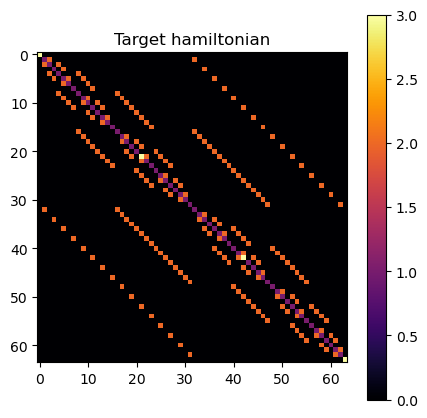

In [21]:
# set the qibo backend (we suggest qibojit if N >= 20)
set_backend("qibojit", platform="numba")

# hamiltonian parameters
nqubits = 6
seed = 10

# define the hamiltonian
# h0 = random_hermitian(2**nqubits, seed=seed)
h0 = hamiltonians.XXZ(nqubits=nqubits)
dbi = DoubleBracketIteration(
    # Hamiltonian(nqubits, h0),
    h0,
    mode=DoubleBracketGeneratorType.single_commutator,
    scheduling=DoubleBracketScheduling.simulated_annealing,
    cost=DoubleBracketCostFunction.off_diagonal_norm
)
# vosualize the matrix
visualize_matrix(dbi.h.matrix, title="Target hamiltonian")
print(dbi.off_diagonal_norm)

In [22]:
# initialize Pauli-basis
pauli_operator_dict = generate_pauli_operator_dict(nqubits, 1)
pauli_operators = list(pauli_operator_dict.values())
d_coef_pauli = np.ones(nqubits)
# d_coef_pauli = np.ones(nqubits+int(nqubits*(nqubits-1)/2))
d_coef_pauli = d_coef_pauli + np.random.rand(len(d_coef_pauli))
d_pauli = sum([d_coef_pauli[i] * pauli_operators[i] for i in range(len(d_coef_pauli))])
s = dbi.choose_step(d_pauli)
loss_before_gd = dbi.loss(s, d_pauli)

[Qibo 0.2.9|WARNING|2024-06-05 15:05:46]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.9|WARNING|2024-06-05 15:05:46]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.9|WARNING|2024-06-05 15:05:46]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.9|WARNING|2024-06-05 15:05:46]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.9|WARNING|2024-06-05 15:05:46]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.9|WARNING|2024-06-05 15:05:46]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.


In [16]:
# Use training to find a better d
train_space = np.linspace(100,1001, 5)
a = []
t = []
for train_epochs in train_space:
    t0 = time.time()
    print("train epochs", int(train_epochs))
    d_train_coef, d_train, s_train, loss_train = gradient_descent_step(dbi, int(train_epochs), d_coef_pauli, ParameterizationTypes.pauli, pauli_operator_dict, pauli_parameterization_order=1, num_check_points=1)
    print(dbi.loss(s_train, d_train))
    a.append(loss_train)
    print("time:", time.time()-t0)
    t.append(time.time()-t0)

train epochs 100


KeyboardInterrupt: 

In [13]:
d_train_coef, d_train, s_train, loss_train = gradient_descent_step(dbi, 1000, d_coef_pauli, ParameterizationTypes.pauli, pauli_operator_dict, pauli_parameterization_order=1, num_check_points=5)
print(loss_train)

[11.977332628247343, 12.726875414255964, 11.702197720944019, 11.415275326382892, 11.080831360589599]
11.080831360589599


In [8]:
dbi = DoubleBracketIteration(
    h0,
    mode=DoubleBracketGeneratorType.single_commutator,
    scheduling=DoubleBracketScheduling.grid_search,
    cost=DoubleBracketCostFunction.off_diagonal_norm
)
# initialize Pauli-basis
pauli_operator_dict = generate_pauli_operator_dict(nqubits, 2)
pauli_operators = list(pauli_operator_dict.values())
d_coef_pauli = np.ones(nqubits+int(nqubits*(nqubits-1)/2))
d_coef_pauli = d_coef_pauli + np.random.rand(len(d_coef_pauli))
d_pauli = sum([d_coef_pauli[i] * pauli_operators[i] for i in range(len(d_coef_pauli))])
s = dbi.choose_step(d_pauli)
loss_before_gd_2 = dbi.loss(s, d_pauli)

[Qibo 0.2.9|WARNING|2024-06-05 12:24:17]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.9|WARNING|2024-06-05 12:24:17]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.9|WARNING|2024-06-05 12:24:17]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.9|WARNING|2024-06-05 12:24:17]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.9|WARNING|2024-06-05 12:24:17]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.9|WARNING|2024-06-05 12:24:17]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.9|WARNING|2024-06-05 12:24:17]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.9|WARNING|2024-06-05 12:24:17]: Calculating the dens

In [9]:
# Use training to find a better d
train_space = np.linspace(300,1001, 8)
a2 = []
t2 = []
for train_epochs in train_space:
    t0 = time.time()
    d_train_coef, d_train, s_train = gradient_descent_step(dbi, int(train_epochs), d_coef_pauli, ParameterizationTypes.pauli, pauli_operator_dict, pauli_parameterization_order=2)
    print(dbi.loss(s_train, d_train))
    a2.append(dbi.loss(s_train, d_train))
    print("time:", time.time()-t0)
    t2.append(time.time()-t0)

KeyboardInterrupt: 

In [ ]:
max_evals_space = np.linspace(100, 500, 5)
b = []
tt = []
for max_evals in max_evals_space:
    t0 = time.time()
    d_train_coef, d_train, s_train = gradient_descent(dbi, d_coef_pauli, ParameterizationTypes.pauli, pauli_operator_dict, max_evals=max_evals, pauli_parameterization_order=2)
    print(dbi.loss(s_train, d_train))
    b.append(dbi.loss(s_train, d_train))
    print("time:", time.time()-t0)
    tt.append(time.time()-t0)

13.695106918853941
time: 0.13807296752929688
13.694894464288502
time: 0.2592329978942871
13.694881457071391
time: 0.40558791160583496
13.694896603628518
time: 0.5757908821105957
13.69488189227997
time: 0.760767936706543


In [ ]:
dbi = DoubleBracketIteration(
    h0,
    mode=DoubleBracketGeneratorType.single_commutator,
    scheduling=DoubleBracketScheduling.grid_search,
    cost=DoubleBracketCostFunction.off_diagonal_norm
)
initial_loss = dbi.off_diagonal_norm
s = dbi.choose_step(num_evals=400)
dbi(step=s)
canonical_loss = dbi.off_diagonal_norm

Text(0, 0.5, 'Off-diagonal norm')

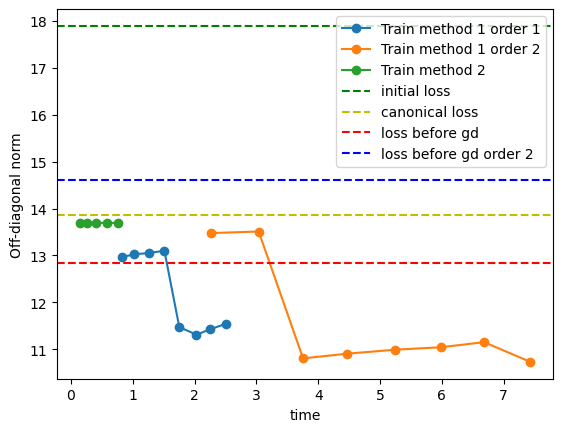

In [ ]:
plt.plot(t, a, label='Train method 1 order 1', marker='o')
plt.plot(t2, a2, label='Train method 1 order 2', marker='o')
plt.plot(tt, b, label='Train method 2', marker='o')
plt.axhline(initial_loss, color='g',linestyle='--',label="initial loss")
plt.axhline(canonical_loss, color='y',linestyle='--',label="canonical loss")
plt.axhline(loss_before_gd, color='r',linestyle='--',label="loss before gd")
plt.axhline(loss_before_gd_2, color='b',linestyle='--',label="loss before gd order 2")
plt.legend()
plt.xlabel('time')
plt.ylabel('Off-diagonal norm')

## Code testing with 

In [ ]:
a = 600
n = 1
b = 600//1
for i in range(a):
    if i%b==0 and i!=0:
        print(i)

600


In [5]:
param_dict = gradient_descent_initial_d_ideas(nqubits, pauli_operator_dict=pauli_operator_dict)

In [6]:
param_dict

{'uniform': array([1., 1., 1., 1., 1.]),
 'uniform_order': array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]),
 'random': array([0.99555646, 0.31669588, 0.81520408, 0.96202768, 0.50701678]),
 'uniform_random': array([1.42799827, 0.87808353, 0.72220414, 0.92036814, 0.83367053]),
 'uniform_order_random': array([ 0.78473771, -0.12884785,  0.79324212,  0.8897473 ,  0.54372214,
         0.41834669,  0.31004365,  0.80470866,  0.87891823,  0.41713155,
         0.66418617, -0.10594432,  0.6774129 ,  0.40131583,  0.04872044]),
 'linear': array([0.  , 0.25, 0.5 , 0.75, 1.  ])}